# Advanced Lab Session: Non-Linear Dimension Reduction and Latent Variables

Welcome to the advanced lab session on Dimension Reduction and Latent Variables. In this session, we will explore powerful non-linear techniques that extend beyond Principal Component Analysis (PCA).

By the end of this lab, you will understand:
1. The comparative strengths and weaknesses of **PCA, t-SNE, and UMAP** for visualizing high-dimensional data.
2. How **Autoencoders** learn latent representations and perform non-linear feature extraction.
3. How **Sparse Autoencoders** encourage disentangled and interpretable feature representations.
4. The generative capabilities of **Variational Autoencoders (VAEs)**.

You will also complete a coding exercise to build and test a VAE.

---

## Part 1: Comparing PCA, t-SNE, and UMAP

We will use the classic **Digits dataset** (8x8 images of handwritten digits) to compare how these three methods handle high-dimensional data.

### 1.1 Setup and Data Loading

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Set random seed for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Load the digits dataset
digits = load_digits()
X = digits.data
y = digits.target

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Original data shape: {X_scaled.shape} (64 pixels per image)")
print(f"Number of classes: {len(np.unique(y))} (Digits 0-9)")

Original data shape: (1797, 64) (64 pixels per image)
Number of classes: 10 (Digits 0-9)


### 1.2 Visual Comparison

Let's apply all three methods and plot them side-by-side.

/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


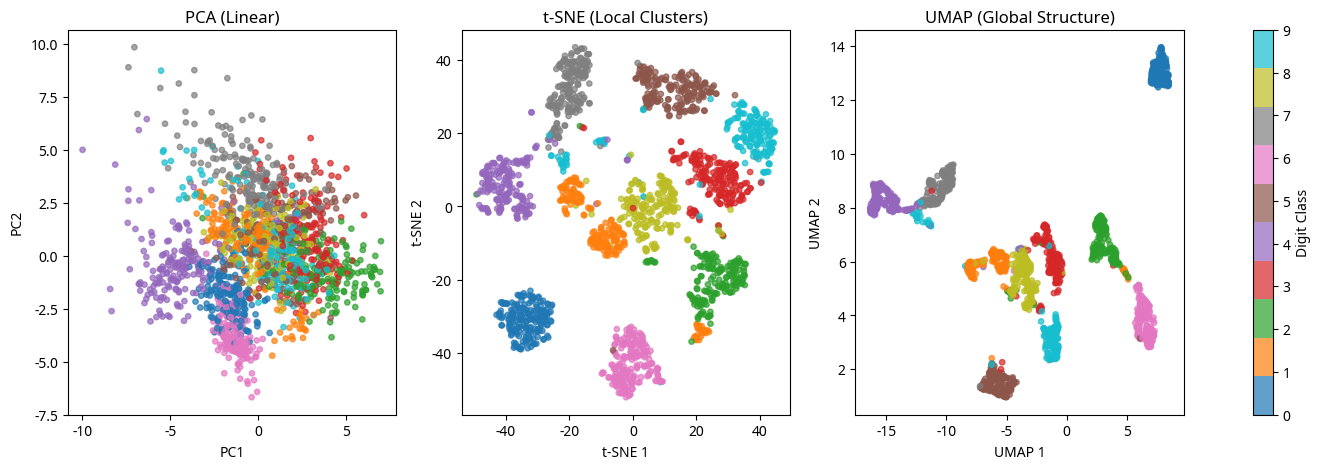

In [2]:
# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Apply t-SNE
tsne = TSNE(n_components=2, perplexity=30, init='pca', random_state=42, max_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)

# Apply UMAP
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
X_umap = reducer.fit_transform(X_scaled)

# Plot comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# PCA
scatter = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='tab10', alpha=0.7, s=15)
axes[0].set_title('PCA (Linear)')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

# t-SNE
axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='tab10', alpha=0.7, s=15)
axes[1].set_title('t-SNE (Local Clusters)')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')

# UMAP
axes[2].scatter(X_umap[:, 0], X_umap[:, 1], c=y, cmap='tab10', alpha=0.7, s=15)
axes[2].set_title('UMAP (Global Structure)')
axes[2].set_xlabel('UMAP 1')
axes[2].set_ylabel('UMAP 2')

plt.colorbar(scatter, ax=axes.ravel().tolist(), label='Digit Class', ticks=range(10))
plt.show()

### Reflection Questions (Part 1)
1. **PCA:** Why do many digit classes overlap in the center of the PCA plot?
2. **t-SNE vs UMAP:** Both methods separate the digits well. However, look at the relative distances between the clusters. How does UMAP's preservation of global structure differ from t-SNE?

---

## Part 2: Autoencoders for Latent Representation

An Autoencoder is a neural network designed to learn an identity function in an unsupervised way to reconstruct the original input while compressing the data in the process. It consists of an **Encoder** (maps input to a latent space) and a **Decoder** (maps latent space back to the original input space).

### 2.1 Building a Standard Autoencoder

We will build a Multi-Layer Perceptron (MLP) autoencoder to compress the 64-dimensional digits down to a 16-dimensional latent space, and then reconstruct them.

In [3]:
# Convert data to PyTorch tensors
X_tensor = torch.FloatTensor(X_scaled)
dataset = TensorDataset(X_tensor, X_tensor)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

# Define the Standard Autoencoder
class Autoencoder(nn.Module):
    def __init__(self, latent_dim=16):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, latent_dim),
            nn.ReLU() # Non-linear latent space
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 64)
        )

    def forward(self, x):
        latent = self.encoder(x)
        reconstructed = self.decoder(latent)
        return reconstructed, latent

# Initialize model, loss, and optimizer
ae_model = Autoencoder(latent_dim=16)
criterion = nn.MSELoss()
optimizer = optim.Adam(ae_model.parameters(), lr=0.01)

# Training loop
epochs = 50
ae_losses = []

for epoch in range(epochs):
    epoch_loss = 0
    for batch_x, _ in dataloader:
        optimizer.zero_grad()
        reconstructed, _ = ae_model(batch_x)
        loss = criterion(reconstructed, batch_x)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    ae_losses.append(epoch_loss / len(dataloader))

print(f'Standard AE Final Loss: {ae_losses[-1]:.4f}')

Standard AE Final Loss: 0.1778


### 2.2 Analyzing the Latent Representation

Let's look at the activations of the 16 latent neurons for a few examples.

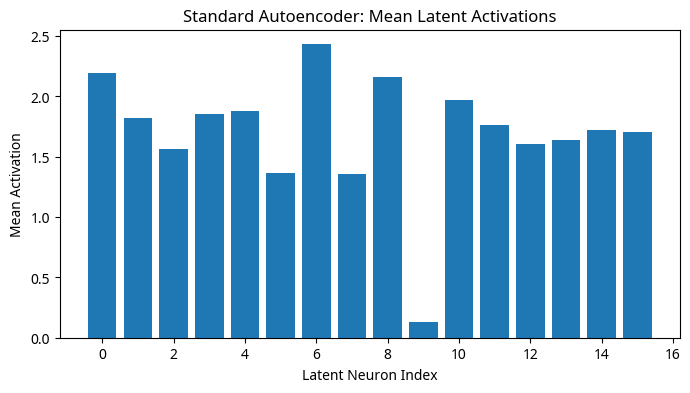

In [4]:
# Extract latent representations
ae_model.eval()
with torch.no_grad():
    _, X_ae_latent = ae_model(X_tensor)
    X_ae_latent = X_ae_latent.numpy()

# Plot the mean activation of each latent neuron across the dataset
plt.figure(figsize=(8, 4))
plt.bar(range(16), np.mean(X_ae_latent, axis=0))
plt.title('Standard Autoencoder: Mean Latent Activations')
plt.xlabel('Latent Neuron Index')
plt.ylabel('Mean Activation')
plt.show()

Notice that many neurons are active simultaneously. The representation is "dense," meaning the features are entangled.

---

## Part 3: Sparse Autoencoders for Feature Extraction

To encourage the network to learn more interpretable, disentangled features, we can add a sparsity penalty to the latent layer. This is analogous to Sparse PCA, but for non-linear neural networks.

We will add an **L1 regularization** term to the latent activations during training.

### 3.1 Building a Sparse Autoencoder

In [5]:
# Initialize Sparse Autoencoder (same architecture)
sae_model = Autoencoder(latent_dim=16)
optimizer_sae = optim.Adam(sae_model.parameters(), lr=0.01)

# Sparsity hyperparameter
l1_lambda = 1e-3

# Training loop with L1 penalty on latent activations
sae_losses = []

for epoch in range(epochs):
    epoch_loss = 0
    for batch_x, _ in dataloader:
        optimizer_sae.zero_grad()
        reconstructed, latent = sae_model(batch_x)
        
        # Standard reconstruction loss
        mse_loss = criterion(reconstructed, batch_x)
        
        # L1 Sparsity penalty on the latent layer
        l1_loss = torch.mean(torch.abs(latent))
        
        # Total loss
        loss = mse_loss + l1_lambda * l1_loss
        
        loss.backward()
        optimizer_sae.step()
        epoch_loss += loss.item()
    sae_losses.append(epoch_loss / len(dataloader))

print(f'Sparse AE Final Total Loss: {sae_losses[-1]:.4f}')

Sparse AE Final Total Loss: 0.2112


### 3.2 Comparing Latent Representations

Let's compare the mean activations of the Sparse Autoencoder to the Standard Autoencoder.

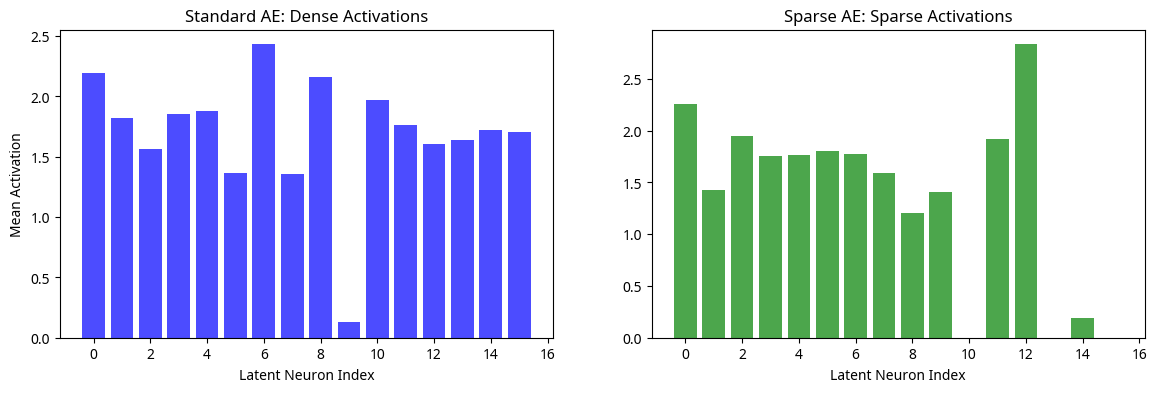

In [6]:
# Extract sparse latent representations
sae_model.eval()
with torch.no_grad():
    _, X_sae_latent = sae_model(X_tensor)
    X_sae_latent = X_sae_latent.numpy()

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(range(16), np.mean(X_ae_latent, axis=0), color='blue', alpha=0.7)
axes[0].set_title('Standard AE: Dense Activations')
axes[0].set_xlabel('Latent Neuron Index')
axes[0].set_ylabel('Mean Activation')

axes[1].bar(range(16), np.mean(X_sae_latent, axis=0), color='green', alpha=0.7)
axes[1].set_title('Sparse AE: Sparse Activations')
axes[1].set_xlabel('Latent Neuron Index')

plt.show()

### Reflection Questions (Part 2 & 3)
1. How does the L1 penalty change the distribution of the latent activations?
2. Why might a sparse representation be more useful for downstream tasks (like classification or interpretation) compared to a dense representation?

---

## Part 4: Student Coding Exercise (Variational Autoencoder)

Standard and Sparse Autoencoders are deterministic. A **Variational Autoencoder (VAE)** is a probabilistic generative model. Instead of mapping an input to a fixed vector, the encoder maps it to a *distribution* (mean $\mu$ and log-variance $\log\sigma^2$). We then sample from this distribution using the **Reparameterization Trick** and decode the sample.

**Your Task:**
1. Complete the `reparameterize` function in the VAE class below.
2. Complete the VAE loss function, which is the sum of the Reconstruction Loss (MSE) and the Kullback-Leibler (KL) Divergence.
3. Train the VAE and plot the 2D latent space (using the $\mu$ values).

Write your code in the block below:

In [7]:
# --- STUDENT EXERCISE ---

class VAE(nn.Module):
    def __init__(self, latent_dim=2):
        super(VAE, self).__init__()
        # Encoder
        self.fc1 = nn.Linear(64, 32)
        self.fc_mu = nn.Linear(32, latent_dim)
        self.fc_logvar = nn.Linear(32, latent_dim)
        
        # Decoder
        self.fc3 = nn.Linear(latent_dim, 32)
        self.fc4 = nn.Linear(32, 64)
        
        self.relu = nn.ReLU()

    def encode(self, x):
        h1 = self.relu(self.fc1(x))
        return self.fc_mu(h1), self.fc_logvar(h1)

    def reparameterize(self, mu, logvar):
        # TODO 1: Implement the reparameterization trick
        # std = exp(0.5 * logvar)
        # eps = random normal tensor of same shape as std
        # return mu + eps * std
        pass

    def decode(self, z):
        h3 = self.relu(self.fc3(z))
        return self.fc4(h3)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

def vae_loss_function(recon_x, x, mu, logvar):
    # TODO 2: Implement the VAE loss (MSE + KL Divergence)
    # MSE = nn.MSELoss(reduction='sum')(recon_x, x)
    # KLD = -0.5 * sum(1 + logvar - mu^2 - exp(logvar))
    # return MSE + KLD
    pass

# TODO 3: Initialize VAE, optimizer, and write the training loop
# ...

# TODO 4: Extract the mu values for the entire dataset and plot them as a scatter plot colored by digit class
# ...
